# Deteksi Video Watermark Tahan Kompresi — Validated Pipeline V7

Notebook ini mengganti pipeline lama yang mengalami **shortcut collapse**: decoder lama
selalu menjawab `sabila`, bahkan pada video tanpa watermark. Versi ini tidak meneruskan
checkpoint lama dan hanya menyatakan sistem berhasil jika seluruh kontrol berikut lolos:

1. payload acak yang belum pernah dilihat dapat diekstrak kembali;
2. video tanpa watermark tidak terdeteksi sebagai `sabila`;
3. watermark lain tidak salah dikenali sebagai `sabila`;
4. `sabila` tetap terbaca setelah H.264, H.265, dan neural codec;
5. evaluasi akhir hanya memakai video test yang tidak masuk training/validation;
6. neural codec menghasilkan entropy-coded bitstream nyata, bukan video FFV1 yang disebut
   sebagai hasil kompresi;
7. ukuran kompresi dibandingkan pada frame count, resolusi, dan durasi yang sama.

**Penting:** jalankan semua sel secara berurutan. Jika validation gate gagal, notebook tetap
menyelesaikan laporan diagnostik tetapi tidak memberi status berhasil.


## Perubahan metodologis

- Training selalu memakai payload 48-bit acak; `sabila` baru digunakan saat kalibrasi dan test.
- Decoder mempunyai dua keluaran: payload dan probabilitas keberadaan watermark.
- Decoder hanya memprediksi 48 bit unik; redundansi diperoleh dari probability voting antar-frame.
- Ambang deteksi dikalibrasi secara empiris dari validation positives dan negatives.
- Detection Accuracy dihitung dari TP, TN, FP, dan FN; bukan hanya proporsi sampel positif.
- H.264/H.265 diuji pada CRF 23, 28, 35, dan 40.
- Neural codec memakai model CompressAI dengan `compress()`/`decompress()` dan container `.nvc`.
- PSNR/SSIM imperceptibility dihitung antara frame asli dan frame ber-watermark.
- BPP, bitrate, dan compression factor dihitung dari bitstream dengan input identik.
- CACS lama dihapus karena keputusan akhirnya hanya BER dan asumsi FPR-nya tidak valid.

- Curriculum V7 berbasis kelulusan performa; tahap kompresi tidak dibuka oleh nomor epoch.
- Status `Terdeteksi` mensyaratkan 48/48 bit cocok tepat, bukan BER longgar.


In [14]:
# 1. Setup Colab
from google.colab import drive
drive.mount('/content/drive')

!pip install -q kagglehub opencv-python-headless scikit-image pandas matplotlib tqdm compressai
!apt-get -qq update
!apt-get -qq install -y ffmpeg

print('Dependency siap.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Dependency siap.


In [15]:
# 2. Import dan konfigurasi eksperimen
import gc
import hashlib
import json
import math
import os
import random
import re
import struct
import subprocess
import tempfile
from collections import defaultdict
from pathlib import Path

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from tqdm.auto import tqdm

SEED = 42
FRAME_SIZE = (128, 128)          # (height, width), kompatibel dengan downsampling codec
CLIP_FRAMES = 12                 # frame per langkah; clip loss mengikuti agregasi temporal
MAX_EVAL_FRAMES = 64             # frame per video untuk validation/test
PAYLOAD_BITS = 48                # 6 karakter ASCII
TEMPORAL_REPEAT = 1
CODE_BITS = PAYLOAD_BITS
TARGET_TEXT = 'sabila'
CONTROL_TEXT = 'kontro'

MAX_TRAIN_VIDEOS = 80
MAX_VAL_VIDEOS = 12
MAX_TEST_VIDEOS = 12

EPOCHS = 160
STEPS_PER_EPOCH = 60
VALIDATE_EVERY = 2
EARLY_STOP_PATIENCE = 3
RESET_V7_TRAINING = False

OUTPUT_ROOT = Path('/content/drive/MyDrive/Video_data/output/v7_validated')
MODEL_DIR = OUTPUT_ROOT / 'models'
BITSTREAM_DIR = OUTPUT_ROOT / 'bitstreams'
REPORT_DIR = OUTPUT_ROOT / 'reports'
for directory in (OUTPUT_ROOT, MODEL_DIR, BITSTREAM_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

KAGGLE_DATASET_SLUG = 'abdallahwagih/ucf101-videos'
DATASET_ROOT = Path(kagglehub.dataset_download(KAGGLE_DATASET_SLUG))
print('Dataset:', DATASET_ROOT)


Device: cuda
Using Colab cache for faster access to the 'ucf101-videos' dataset.
Dataset: /kaggle/input/ucf101-videos


In [16]:
# 3. Discovery dan split anti-leakage
VIDEO_EXTENSIONS = {'.avi', '.mp4', '.mov', '.mkv'}
all_video_paths = sorted(
    path for path in DATASET_ROOT.rglob('*')
    if path.is_file() and path.suffix.lower() in VIDEO_EXTENSIONS
)
if not all_video_paths:
    raise FileNotFoundError(f'Tidak ada video di {DATASET_ROOT}')

def class_name(path):
    match = re.match(r'^v_(.+?)_g\d+_c\d+$', path.stem)
    return match.group(1) if match else path.parent.name

def group_key(path):
    match = re.search(r'_g(\d+)_', path.stem)
    group = match.group(1) if match else path.stem
    return f'{class_name(path)}:{group}'

def has_part(path, expected):
    return expected.lower() in {part.lower() for part in path.relative_to(DATASET_ROOT).parts}

def group_split(paths, fractions=(0.70, 0.15, 0.15), seed=SEED):
    groups = sorted({group_key(p) for p in paths})
    rng = random.Random(seed)
    rng.shuffle(groups)
    n = len(groups)
    n_train = max(1, int(n * fractions[0]))
    n_val = max(1, int(n * fractions[1]))
    train_groups = set(groups[:n_train])
    val_groups = set(groups[n_train:n_train + n_val])
    test_groups = set(groups[n_train + n_val:])
    return (
        [p for p in paths if group_key(p) in train_groups],
        [p for p in paths if group_key(p) in val_groups],
        [p for p in paths if group_key(p) in test_groups],
    )

explicit_train = [p for p in all_video_paths if has_part(p, 'train')]
explicit_test = [p for p in all_video_paths if has_part(p, 'test')]

if explicit_train and explicit_test:
    # Test bawaan dataset tidak pernah dipakai untuk training atau pemilihan checkpoint.
    train_candidates, val_candidates, _ = group_split(
        explicit_train, fractions=(0.80, 0.20, 0.0)
    )
    test_candidates = explicit_test
    split_source = 'folder train/test dataset + validation berbasis group dari train'
else:
    train_candidates, val_candidates, test_candidates = group_split(all_video_paths)
    split_source = 'group-aware split 70/15/15'

def balanced_sample(paths, limit, seed):
    by_class = defaultdict(list)
    for path in paths:
        by_class[class_name(path)].append(path)
    rng = random.Random(seed)
    for values in by_class.values():
        rng.shuffle(values)
    chosen = []
    classes = sorted(by_class)
    while len(chosen) < min(limit, len(paths)):
        progressed = False
        for cls in classes:
            if by_class[cls] and len(chosen) < limit:
                chosen.append(by_class[cls].pop())
                progressed = True
        if not progressed:
            break
    return chosen

TRAIN_PATHS = balanced_sample(train_candidates, MAX_TRAIN_VIDEOS, SEED + 1)
VAL_PATHS = balanced_sample(val_candidates, MAX_VAL_VIDEOS, SEED + 2)
TEST_PATHS = balanced_sample(test_candidates, MAX_TEST_VIDEOS, SEED + 3)

train_set, val_set, test_set = map(set, (TRAIN_PATHS, VAL_PATHS, TEST_PATHS))
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
train_groups = {group_key(p) for p in TRAIN_PATHS}
val_groups = {group_key(p) for p in VAL_PATHS}
test_groups = {group_key(p) for p in TEST_PATHS}
assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

print(f'Ditemukan: {len(all_video_paths)} video')
print('Sumber split:', split_source)
print(f'Train/Val/Test dipakai: {len(TRAIN_PATHS)}/{len(VAL_PATHS)}/{len(TEST_PATHS)}')
print('Kelas train:', sorted({class_name(p) for p in TRAIN_PATHS}))
print('Leakage check: LULUS')


Ditemukan: 818 video
Sumber split: folder train/test dataset + validation berbasis group dari train
Train/Val/Test dipakai: 80/12/12
Kelas train: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
Leakage check: LULUS


In [17]:
# 4. I/O video dengan frame count, resolusi, dan durasi yang konsisten
def _resize_rgb(frame_bgr, frame_size=FRAME_SIZE):
    frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (frame_size[1], frame_size[0]), interpolation=cv2.INTER_AREA)
    return frame.astype(np.float32) / 255.0

def sample_clip(path, clip_frames=CLIP_FRAMES):
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise ValueError(f'Video tidak dapat dibaca: {path}')
    start = random.randint(0, max(total - clip_frames, 0))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    frames = []
    for _ in range(clip_frames):
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(_resize_rgb(frame))
    cap.release()
    if not frames:
        raise ValueError(f'Tidak ada frame: {path}')
    while len(frames) < clip_frames:
        frames.append(frames[-1].copy())
    return np.stack(frames)

def load_eval_frames(path, max_frames=MAX_EVAL_FRAMES):
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise ValueError(f'Video tidak dapat dibaca: {path}')
    indices = np.linspace(0, total - 1, min(max_frames, total), dtype=int)
    frames = []
    for index in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(index))
        ok, frame = cap.read()
        if ok:
            frames.append(_resize_rgb(frame))
    cap.release()
    if not frames:
        raise ValueError(f'Tidak ada frame evaluasi: {path}')
    return np.stack(frames), float(fps)

def frames_to_tensor(frames):
    return torch.from_numpy(np.asarray(frames)).permute(0, 3, 1, 2).float().to(device)

def tensor_to_frames(tensor):
    return tensor.detach().clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()

def read_encoded_video(path, expected_frames=None):
    cap = cv2.VideoCapture(str(path))
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(_resize_rgb(frame))
    cap.release()
    if not frames:
        raise RuntimeError(f'FFmpeg tidak menghasilkan frame terbaca: {path}')
    if expected_frames is not None:
        frames = frames[:expected_frames]
        while len(frames) < expected_frames:
            frames.append(frames[-1].copy())
    return np.stack(frames)

def ffmpeg_encode(frames, output_path, fps, codec, crf):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    frames_u8 = np.clip(np.asarray(frames) * 255.0, 0, 255).astype(np.uint8)
    height, width = frames_u8.shape[1:3]
    cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'rgb24', '-s', f'{width}x{height}',
        '-r', str(fps), '-i', '-', '-an', '-c:v', codec,
        '-crf', str(crf), '-preset', 'fast', '-pix_fmt', 'yuv420p', str(output_path),
    ]
    result = subprocess.run(cmd, input=frames_u8.tobytes(), capture_output=True)
    if result.returncode != 0 or not output_path.exists() or output_path.stat().st_size == 0:
        raise RuntimeError(result.stderr.decode(errors='replace'))
    return output_path

print('Video I/O siap.')


Video I/O siap.


In [18]:
# 5. Payload 48-bit, encoder, dan decoder dengan presence head
def text_to_payload(text):
    raw = text.encode('ascii')
    if len(raw) != PAYLOAD_BITS // 8:
        raise ValueError(f'Teks harus tepat {PAYLOAD_BITS // 8} karakter ASCII')
    return torch.tensor(
        [[int(bit) for byte in raw for bit in f'{byte:08b}']],
        dtype=torch.float32,
        device=device,
    )

def payload_to_text(payload_bits):
    bits = np.asarray(payload_bits).astype(int).reshape(-1)[:PAYLOAD_BITS]
    values = [int(''.join(map(str, bits[i:i + 8])), 2) for i in range(0, PAYLOAD_BITS, 8)]
    return bytes(values).decode('ascii', errors='replace')

def channel_encode(payload):
    """Satu codeword berisi 48 bit unik; codeword diulang pada seluruh frame."""
    return payload

def aggregate_decode(bit_logits, presence_logits):
    """Probability voting antar-frame menjadi satu payload 48-bit."""
    payload_probs = torch.sigmoid(bit_logits).mean(dim=0)
    payload_bits = (payload_probs >= 0.5).float()
    presence = torch.sigmoid(presence_logits).mean().item()
    return payload_bits.cpu().numpy(), payload_probs.cpu().numpy(), float(presence)
class WatermarkEncoder(nn.Module):
    def __init__(self, code_bits=CODE_BITS, channels=80, strength=0.10):
        super().__init__()
        self.strength = strength
        self.project = nn.Linear(code_bits, 16 * 8 * 8)
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(16, 32, 4, 2, 1), nn.GroupNorm(8, 32), nn.SiLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.GroupNorm(4, 16), nn.SiLU(),
            nn.ConvTranspose2d(16, 8, 4, 2, 1), nn.GroupNorm(2, 8), nn.SiLU(),
            nn.ConvTranspose2d(8, 4, 4, 2, 1), nn.GroupNorm(2, 4), nn.SiLU(),
        )
        self.body = nn.Sequential(
            nn.Conv2d(7, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv2d(channels, 3, 3, padding=1),
        )

    def forward(self, frames, code):
        batch = frames.shape[0]
        message = self.project(code).view(batch, 16, 8, 8)
        message = self.upsample(message)
        residual = torch.tanh(self.body(torch.cat([frames, message], dim=1))) * self.strength
        return torch.clamp(frames + residual, 0, 1), residual

class WatermarkDecoder(nn.Module):
    def __init__(self, code_bits=CODE_BITS, channels=80):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, channels, 3, 2, 1), nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, 2, 1), nn.GroupNorm(8, channels), nn.SiLU(),
            nn.Conv2d(channels, channels * 2, 3, 2, 1), nn.GroupNorm(8, channels * 2), nn.SiLU(),
            nn.Conv2d(channels * 2, channels * 2, 3, 2, 1), nn.GroupNorm(8, channels * 2), nn.SiLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels * 2 * 4 * 4, 384),
            nn.SiLU(),
            nn.Dropout(0.05),
        )
        self.payload_head = nn.Linear(384, code_bits)
        self.presence_head = nn.Linear(384, 1)

    def forward(self, frames):
        hidden = self.shared(self.features(frames))
        return self.payload_head(hidden), self.presence_head(hidden).squeeze(1)

encoder = WatermarkEncoder().to(device)
decoder = WatermarkDecoder().to(device)

assert payload_to_text(text_to_payload(TARGET_TEXT).cpu().numpy()) == TARGET_TEXT
print(f'Payload/codeword: {PAYLOAD_BITS} bit unik; redundansi memakai voting antar-frame.')


Payload/codeword: 48 bit unik; redundansi memakai voting antar-frame.


In [19]:
# 6. Neural codec nyata: entropy-coded bitstream melalui CompressAI
from compressai.zoo import bmshj2018_factorized

_neural_models = {}

def get_neural_model(quality):
    quality = int(quality)
    if quality not in _neural_models:
        model = bmshj2018_factorized(quality=quality, pretrained=True).to(device).eval()
        model.update(force=True)
        for parameter in model.parameters():
            parameter.requires_grad_(False)
        _neural_models[quality] = model
    return _neural_models[quality]

def neural_encode(frames, output_path, fps, quality):
    model = get_neural_model(quality)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    entries = []
    with torch.inference_mode():
        for start in range(0, len(frames), 8):
            x = frames_to_tensor(frames[start:start + 8])
            packed = model.compress(x)
            shape = tuple(map(int, packed['shape']))
            for batch_index in range(x.shape[0]):
                streams = [stream_group[batch_index] for stream_group in packed['strings']]
                entries.append((shape, streams))

    header = json.dumps({
        'codec': 'bmshj2018-factorized', 'quality': int(quality), 'fps': float(fps),
        'frames': len(entries), 'height': int(frames.shape[1]), 'width': int(frames.shape[2]),
    }).encode('utf-8')
    with output_path.open('wb') as handle:
        handle.write(b'NVC1')
        handle.write(struct.pack('<I', len(header)))
        handle.write(header)
        for shape, streams in entries:
            handle.write(struct.pack('<IIH', shape[0], shape[1], len(streams)))
            for stream in streams:
                handle.write(struct.pack('<I', len(stream)))
                handle.write(stream)
    return output_path

def neural_decode(input_path):
    input_path = Path(input_path)
    with input_path.open('rb') as handle:
        if handle.read(4) != b'NVC1':
            raise ValueError('Bukan container NVC1')
        header_len = struct.unpack('<I', handle.read(4))[0]
        header = json.loads(handle.read(header_len).decode('utf-8'))
        model = get_neural_model(header['quality'])
        entries = []
        for _ in range(header['frames']):
            h, w, n_streams = struct.unpack('<IIH', handle.read(10))
            streams = []
            for _ in range(n_streams):
                size = struct.unpack('<I', handle.read(4))[0]
                streams.append(handle.read(size))
            entries.append(((h, w), streams))

        frames = []
        with torch.inference_mode():
            for start in range(0, len(entries), 8):
                batch = entries[start:start + 8]
                shape = batch[0][0]
                n_streams = len(batch[0][1])
                strings = [[entry[1][stream_index] for entry in batch]
                           for stream_index in range(n_streams)]
                result = model.decompress(strings, shape)['x_hat']
                frames.extend(tensor_to_frames(result))
    return np.stack(frames), header

# Smoke test dilakukan nanti pada frame dataset; file .nvc adalah bitstream yang diukur.
print('Neural entropy codec siap.')


Neural entropy codec siap.


In [20]:
# 7. Channel training: kompresi nyata dengan BPDA + distorsi ringan
def ffmpeg_bpda(x, codec, crf, fps=25.0):
    with tempfile.TemporaryDirectory() as tmp:
        path = Path(tmp) / 'roundtrip.mp4'
        frames = tensor_to_frames(x)
        ffmpeg_encode(frames, path, fps, codec, crf)
        reconstructed = frames_to_tensor(read_encoded_video(path, len(frames)))
    return x + (reconstructed - x).detach()

def neural_bpda(x, quality):
    model = get_neural_model(quality)
    with torch.no_grad():
        reconstructed = model(x.clamp(0, 1))['x_hat'].clamp(0, 1)
    return x + (reconstructed - x).detach()

def apply_training_channel(x, specification):
    name, level = specification
    if name == 'identity':
        return x
    if name == 'noise':
        noisy = x + torch.randn_like(x) * level
        quantized = torch.clamp(torch.round(noisy * 255) / 255, 0, 1)
        # Straight-through estimator: forward memakai kuantisasi 8-bit, gradien tetap mengalir.
        return x + (quantized - x).detach()
    if name == 'h264':
        return ffmpeg_bpda(x, 'libx264', int(level))
    if name == 'h265':
        return ffmpeg_bpda(x, 'libx265', int(level))
    if name == 'neural':
        return neural_bpda(x, int(level))
    raise ValueError(specification)

TRAINING_STAGES = [
    {
        'name': 'payload_pretrain',
        'strength': 0.10,
        'lr': 8e-4,
        'channels': [('identity', 0), ('identity', 0), ('noise', 0.005)],
        'validation_channels': [('identity', 0), ('noise', 0.005)],
        'presence_weight': 0.05,
        'quality_target_mse': 1e-2,
        'quality_weight': 0.05,
        'min_epochs': 12,
        'min_bit_acc': 0.995,
        'min_exact': 0.85,
        'min_presence': 0.0,
        'min_negative': 0.0,
        'min_psnr': 20.0,
    },
    {
        'name': 'presence_and_quality',
        'strength': 0.055,
        'lr': 5e-4,
        'channels': [
            ('identity', 0), ('noise', 0.005), ('noise', 0.01), ('noise', 0.02),
        ],
        'validation_channels': [('identity', 0), ('noise', 0.02)],
        'presence_weight': 0.50,
        'quality_target_mse': 1e-3,
        'quality_weight': 0.75,
        'min_epochs': 8,
        'min_bit_acc': 0.990,
        'min_exact': 0.85,
        'min_presence': 0.90,
        'min_negative': 0.90,
        'min_psnr': 30.0,
    },
    {
        'name': 'medium_compression',
        'strength': 0.050,
        'lr': 3e-4,
        'channels': [
            ('identity', 0), ('noise', 0.01),
            ('h264', 23), ('h264', 28), ('h265', 23), ('h265', 28),
            ('neural', 5), ('neural', 3),
        ],
        'validation_channels': [('h264', 28), ('h265', 28), ('neural', 5)],
        'presence_weight': 0.50,
        'quality_target_mse': 1e-3,
        'quality_weight': 1.00,
        'min_epochs': 10,
        'min_bit_acc': 0.980,
        'min_exact': 0.80,
        'min_presence': 0.90,
        'min_negative': 0.90,
        'min_psnr': 30.0,
    },
    {
        'name': 'high_compression',
        'strength': 0.040,
        'lr': 2e-4,
        'channels': [
            ('noise', 0.02),
            ('h264', 35), ('h264', 35), ('h264', 40),
            ('h265', 35), ('h265', 35), ('h265', 40),
            ('neural', 3), ('neural', 1), ('neural', 1),
        ],
        'validation_channels': [('h264', 40), ('h265', 40), ('neural', 1)],
        'presence_weight': 0.50,
        'quality_target_mse': 1e-3,
        'quality_weight': 1.25,
        'min_epochs': 12,
        'min_bit_acc': 0.970,
        'min_exact': 0.80,
        'min_presence': 0.90,
        'min_negative': 0.90,
        'min_psnr': 30.0,
    },
]

def stage_passed(stage, metrics):
    return (
        metrics['random_payload_bit_acc'] >= stage['min_bit_acc'] and
        metrics['random_payload_exact_recovery'] >= stage['min_exact'] and
        metrics['presence_tpr'] >= stage['min_presence'] and
        metrics['negative_rejection'] >= stage['min_negative'] and
        metrics['watermark_psnr'] >= stage['min_psnr']
    )

def quick_validation(stage, max_videos=4):
    encoder.eval(); decoder.eval()
    bit_correct = bit_total = exact_correct = sample_total = 0
    positive_presence = []
    negative_rejection = []
    watermark_psnr = []
    with torch.no_grad():
        for path in VAL_PATHS[:max_videos]:
            original = frames_to_tensor(sample_clip(path))
            payload = torch.randint(0, 2, (1, PAYLOAD_BITS), device=device).float()
            codeword = channel_encode(payload).repeat(original.shape[0], 1)
            watermarked, _ = encoder(original, codeword)
            mse = F.mse_loss(watermarked, original).item()
            watermark_psnr.append(-10.0 * math.log10(max(mse, 1e-12)))
            for specification in stage['validation_channels']:
                positive = apply_training_channel(watermarked, specification)
                negative = apply_training_channel(original, specification)
                pos_logits, pos_presence = decoder(positive)
                _, neg_presence = decoder(negative)
                decoded, _, presence = aggregate_decode(pos_logits, pos_presence)
                target = payload.cpu().numpy().reshape(-1)
                matches = int((decoded == target).sum())
                bit_correct += matches
                bit_total += PAYLOAD_BITS
                exact_correct += int(matches == PAYLOAD_BITS)
                sample_total += 1
                positive_presence.append(presence >= 0.5)
                negative_rejection.append(torch.sigmoid(neg_presence).mean().item() < 0.5)
    encoder.train(); decoder.train()
    return {
        'random_payload_bit_acc': bit_correct / max(bit_total, 1),
        'random_payload_exact_recovery': exact_correct / max(sample_total, 1),
        'presence_tpr': float(np.mean(positive_presence)),
        'negative_rejection': float(np.mean(negative_rejection)),
        'watermark_psnr': float(np.mean(watermark_psnr)),
    }

print('Performance-gated training stages siap:', [stage['name'] for stage in TRAINING_STAGES])


Performance-gated training stages siap: ['payload_pretrain', 'presence_and_quality', 'medium_compression', 'high_compression']


In [21]:
# 8. Training V7 — tahap hanya berpindah setelah metrik tahap sebelumnya lulus
config_for_hash = {
    'frame_size': FRAME_SIZE, 'payload_bits': PAYLOAD_BITS,
    'clip_frames': CLIP_FRAMES, 'seed': SEED, 'version': 7,
    'encoder_channels': 80, 'decoder_channels': 80,
    'curriculum': 'performance_gated_v7',
}
config_hash = hashlib.sha256(json.dumps(config_for_hash, sort_keys=True).encode()).hexdigest()[:10]
checkpoint_path = MODEL_DIR / f'checkpoint_v7_{config_hash}.pth'

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(decoder.parameters()), lr=8e-4, weight_decay=1e-5
)
start_epoch = 1
current_stage = 0
stage_epoch = 0
stage_best_score = -math.inf
stage_pass_streak = 0
history = []

if RESET_V7_TRAINING:
    if checkpoint_path.exists():
        checkpoint_path.unlink()
    for stale_best in MODEL_DIR.glob(f'best_v7_stage*_{config_hash}.pth'):
        stale_best.unlink()
    print('RESET_V7_TRAINING aktif: checkpoint dan best model V7 lama dibersihkan.')
elif checkpoint_path.exists():
    saved = torch.load(checkpoint_path, map_location=device)
    if saved.get('config_hash') != config_hash:
        raise RuntimeError('Checkpoint V7 tidak cocok dengan konfigurasi saat ini.')
    encoder.load_state_dict(saved['encoder'])
    decoder.load_state_dict(saved['decoder'])
    optimizer.load_state_dict(saved['optimizer'])
    start_epoch = saved['epoch'] + 1
    current_stage = saved.get('current_stage', 0)
    stage_epoch = saved.get('stage_epoch', 0)
    stage_best_score = saved.get('stage_best_score', -math.inf)
    stage_pass_streak = saved.get('stage_pass_streak', 0)
    history = saved.get('history', [])
    print(f"Resume V7 epoch {start_epoch}, stage {current_stage + 1}: "
          f"{TRAINING_STAGES[current_stage]['name']}")

for epoch in range(start_epoch, EPOCHS + 1):
    stage = TRAINING_STAGES[current_stage]
    encoder.strength = stage['strength']
    for group in optimizer.param_groups:
        group['lr'] = stage['lr']
    stage_epoch += 1
    encoder.train(); decoder.train()
    totals = defaultdict(float)

    for _ in tqdm(range(STEPS_PER_EPOCH),
                  desc=f"Epoch {epoch}/{EPOCHS} | {stage['name']}", leave=False):
        original = frames_to_tensor(sample_clip(random.choice(TRAIN_PATHS)))
        frame_count = original.shape[0]
        payload = torch.randint(0, 2, (1, PAYLOAD_BITS), device=device).float()
        codeword = channel_encode(payload).repeat(frame_count, 1)
        watermarked, residual = encoder(original, codeword)

        specification = random.choice(stage['channels'])
        positive = apply_training_channel(watermarked, specification)
        negative = apply_training_channel(original, specification)
        pos_bits, pos_presence = decoder(positive)
        _, neg_presence = decoder(negative)

        loss_payload_frame = F.binary_cross_entropy_with_logits(pos_bits, codeword)
        clip_logits = pos_bits.mean(dim=0, keepdim=True)
        loss_payload_clip = F.binary_cross_entropy_with_logits(clip_logits, codeword[:1])
        loss_payload = 0.5 * loss_payload_frame + 1.5 * loss_payload_clip
        loss_presence = (
            F.binary_cross_entropy_with_logits(pos_presence, torch.ones_like(pos_presence)) +
            F.binary_cross_entropy_with_logits(neg_presence, torch.zeros_like(neg_presence))
        )
        image_mse = F.mse_loss(watermarked, original)
        # Penalti dinormalisasi terhadap MSE target; tidak lagi kalah skala dari BCE payload.
        loss_quality = F.relu(image_mse - stage['quality_target_mse']) / stage['quality_target_mse']
        loss_bias = residual.mean(dim=(2, 3)).pow(2).mean()
        loss = (
            2.0 * loss_payload + stage['presence_weight'] * loss_presence +
            stage['quality_weight'] * loss_quality + 0.10 * loss_bias
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 5.0)
        optimizer.step()

        with torch.no_grad():
            totals['loss'] += loss.item()
            totals['bit_acc'] += ((pos_bits > 0) == codeword.bool()).float().mean().item()
            totals['presence_tpr'] += float(torch.sigmoid(pos_presence).mean() >= 0.5)
            totals['negative_rejection'] += float(torch.sigmoid(neg_presence).mean() < 0.5)
            totals['image_mse'] += image_mse.item()

    row = {
        'epoch': epoch,
        'stage_index': current_stage + 1,
        'stage_name': stage['name'],
        'stage_epoch': stage_epoch,
        'encoder_strength': encoder.strength,
        'loss': totals['loss'] / STEPS_PER_EPOCH,
        'train_code_bit_acc': totals['bit_acc'] / STEPS_PER_EPOCH,
        'train_presence_tpr': totals['presence_tpr'] / STEPS_PER_EPOCH,
        'train_negative_rejection': totals['negative_rejection'] / STEPS_PER_EPOCH,
        'train_watermark_psnr': -10.0 * math.log10(max(totals['image_mse'] / STEPS_PER_EPOCH, 1e-12)),
    }

    if epoch % VALIDATE_EVERY == 0 or epoch == EPOCHS:
        validation = quick_validation(stage)
        row.update({f'val_{key}': value for key, value in validation.items()})
        score = (
            3.0 * validation['random_payload_bit_acc'] +
            2.0 * validation['random_payload_exact_recovery'] +
            0.5 * validation['presence_tpr'] +
            0.5 * validation['negative_rejection'] +
            0.02 * min(validation['watermark_psnr'], 40.0)
        )
        print(row)
        best_path = MODEL_DIR / f'best_v7_stage{current_stage + 1}_{config_hash}.pth'
        if score > stage_best_score:
            stage_best_score = score
            torch.save({
                'encoder': encoder.state_dict(), 'decoder': decoder.state_dict(),
                'encoder_strength': encoder.strength, 'config_hash': config_hash,
                'epoch': epoch, 'stage_index': current_stage,
                'validation': validation,
            }, best_path)

        passed = stage_epoch >= stage['min_epochs'] and stage_passed(stage, validation)
        stage_pass_streak = stage_pass_streak + 1 if passed else 0
        if stage_pass_streak >= 2:
            if current_stage < len(TRAINING_STAGES) - 1:
                print(f"STAGE LULUS: {stage['name']} -> {TRAINING_STAGES[current_stage + 1]['name']}")
                current_stage += 1
                stage_epoch = 0
                stage_best_score = -math.inf
                stage_pass_streak = 0
            elif stage_pass_streak >= EARLY_STOP_PATIENCE:
                print('FINAL STAGE LULUS stabil. Training dihentikan lebih awal.')
                history.append(row)
                break
    else:
        print(row)

    history.append(row)
    torch.save({
        'encoder': encoder.state_dict(), 'decoder': decoder.state_dict(),
        'optimizer': optimizer.state_dict(), 'encoder_strength': encoder.strength,
        'config_hash': config_hash, 'epoch': epoch,
        'current_stage': current_stage, 'stage_epoch': stage_epoch,
        'stage_best_score': stage_best_score, 'stage_pass_streak': stage_pass_streak,
        'history': history,
    }, checkpoint_path)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Muat best checkpoint dari tahap tertinggi yang benar-benar pernah divalidasi.
best = None
for stage_index in range(len(TRAINING_STAGES) - 1, -1, -1):
    candidate = MODEL_DIR / f'best_v7_stage{stage_index + 1}_{config_hash}.pth'
    if candidate.exists():
        best = torch.load(candidate, map_location=device)
        break
if best is None:
    raise RuntimeError('Belum ada best checkpoint V7.')

encoder.load_state_dict(best['encoder'])
decoder.load_state_dict(best['decoder'])
encoder.strength = best['encoder_strength']
encoder.eval(); decoder.eval()
TRAINING_HIGHEST_STAGE = best['stage_index']
TRAINING_STAGE_NAME = TRAINING_STAGES[TRAINING_HIGHEST_STAGE]['name']
pd.DataFrame(history).to_csv(REPORT_DIR / 'training_history.csv', index=False)
print('Best stage:', TRAINING_STAGE_NAME)
print('Best validation:', best['validation'])
if TRAINING_HIGHEST_STAGE < len(TRAINING_STAGES) - 1:
    print('PERINGATAN: training belum mencapai final high-compression stage.')


Epoch 1/160 | payload_pretrain:   0%|          | 0/60 [00:00<?, ?it/s]

{'epoch': 1, 'stage_index': 1, 'stage_name': 'payload_pretrain', 'stage_epoch': 1, 'encoder_strength': 0.1, 'loss': 2.9319316069285075, 'train_code_bit_acc': 0.5015046338240305, 'train_presence_tpr': 0.4666666666666667, 'train_negative_rejection': 0.6, 'train_watermark_psnr': 22.80111946590216}


Epoch 2/160 | payload_pretrain:   0%|          | 0/60 [00:00<?, ?it/s]

{'epoch': 2, 'stage_index': 1, 'stage_name': 'payload_pretrain', 'stage_epoch': 2, 'encoder_strength': 0.1, 'loss': 2.8845323363939923, 'train_code_bit_acc': 0.5110532492399216, 'train_presence_tpr': 0.5, 'train_negative_rejection': 0.7166666666666667, 'train_watermark_psnr': 21.75702058839313, 'val_random_payload_bit_acc': 0.5, 'val_random_payload_exact_recovery': 0.0, 'val_presence_tpr': 1.0, 'val_negative_rejection': 0.0, 'val_watermark_psnr': 21.571692150389154}


Epoch 3/160 | payload_pretrain:   0%|          | 0/60 [00:00<?, ?it/s]

...

{'epoch': 158, 'stage_index': 1, 'stage_name': 'payload_pretrain', 'stage_epoch': 158, 'encoder_strength': 0.1, 'loss': 0.22808096174461145, 'train_code_bit_acc': 0.9758680601914723, 'train_presence_tpr': 1.0, 'train_negative_rejection': 1.0, 'train_watermark_psnr': 20.93757281937068, 'val_random_payload_bit_acc': 0.9661458333333334, 'val_random_payload_exact_recovery': 0.25, 'val_presence_tpr': 1.0, 'val_negative_rejection': 1.0, 'val_watermark_psnr': 20.863356001198703}


Epoch 159/160 | payload_pretrain:   0%|          | 0/60 [00:00<?, ?it/s]

{'epoch': 159, 'stage_index': 1, 'stage_name': 'payload_pretrain', 'stage_epoch': 159, 'encoder_strength': 0.1, 'loss': 0.28955784210314356, 'train_code_bit_acc': 0.9729745457569758, 'train_presence_tpr': 1.0, 'train_negative_rejection': 1.0, 'train_watermark_psnr': 20.94517575028486}


Epoch 160/160 | payload_pretrain:   0%|          | 0/60 [00:00<?, ?it/s]

{'epoch': 160, 'stage_index': 1, 'stage_name': 'payload_pretrain', 'stage_epoch': 160, 'encoder_strength': 0.1, 'loss': 0.19712667632848024, 'train_code_bit_acc': 0.979832183321317, 'train_presence_tpr': 1.0, 'train_negative_rejection': 1.0, 'train_watermark_psnr': 20.94649635369338, 'val_random_payload_bit_acc': 0.984375, 'val_random_payload_exact_recovery': 0.25, 'val_presence_tpr': 1.0, 'val_negative_rejection': 1.0, 'val_watermark_psnr': 20.887728708377548}
Best stage: payload_pretrain
Best validation: {'random_payload_bit_acc': 0.984375, 'random_payload_exact_recovery': 0.5, 'presence_tpr': 1.0, 'negative_rejection': 1.0, 'watermark_psnr': 20.88768957578252}
PERINGATAN: training belum mencapai final high-compression stage.


In [22]:
# 9. Fungsi bitstream evaluasi dan metrik kualitas
TEST_CODEC_CONFIGS = (
    [('H264', crf) for crf in (23, 28, 35, 40)] +
    [('H265', crf) for crf in (23, 28, 35, 40)] +
    [('NEURAL', quality) for quality in (1, 3, 5)]
)
CALIBRATION_CONFIGS = [('H264', 35), ('H265', 35), ('NEURAL', 1)]

def codec_roundtrip(frames, fps, codec_name, level, output_base):
    output_base = Path(output_base)
    if codec_name == 'H264':
        path = output_base.with_suffix('.mp4')
        ffmpeg_encode(frames, path, fps, 'libx264', level)
        reconstructed = read_encoded_video(path, len(frames))
    elif codec_name == 'H265':
        path = output_base.with_suffix('.mp4')
        ffmpeg_encode(frames, path, fps, 'libx265', level)
        reconstructed = read_encoded_video(path, len(frames))
    elif codec_name == 'NEURAL':
        path = output_base.with_suffix('.nvc')
        neural_encode(frames, path, fps, level)
        reconstructed, _ = neural_decode(path)
    else:
        raise ValueError(codec_name)
    return reconstructed, path, path.stat().st_size

def mean_quality(reference, candidate):
    count = min(len(reference), len(candidate))
    psnr = []
    ssim = []
    for a, b in zip(reference[:count], candidate[:count]):
        psnr.append(peak_signal_noise_ratio(a, b, data_range=1.0))
        ssim.append(structural_similarity(a, b, data_range=1.0, channel_axis=-1))
    return float(np.mean(psnr)), float(np.mean(ssim))

def make_case_frames(original, case_name):
    original_t = frames_to_tensor(original)
    if case_name == 'no_watermark':
        return original.copy(), None
    text = TARGET_TEXT if case_name == 'target' else CONTROL_TEXT
    payload = text_to_payload(text)
    codeword = channel_encode(payload).repeat(original_t.shape[0], 1)
    with torch.inference_mode():
        watermarked, _ = encoder(original_t, codeword)
    return tensor_to_frames(watermarked), payload.cpu().numpy().reshape(-1)

def prediction_from_frames(frames):
    with torch.inference_mode():
        bits, presence = decoder(frames_to_tensor(frames))
        return aggregate_decode(bits, presence)

def payload_ber(expected, predicted):
    return float(np.mean(np.asarray(expected).reshape(-1) != np.asarray(predicted).reshape(-1)))

print('Evaluation helpers siap.')


Evaluation helpers siap.


In [23]:
# 10. Kalibrasi presence threshold; status target mensyaratkan exact 48/48 bit
calibration_rows = []
target_payload_np = text_to_payload(TARGET_TEXT).cpu().numpy().reshape(-1)
control_payload_np = text_to_payload(CONTROL_TEXT).cpu().numpy().reshape(-1)

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)
    for video_index, path in enumerate(tqdm(VAL_PATHS, desc='Calibration')):
        original, fps = load_eval_frames(path, max_frames=32)
        for case_name in ('target', 'no_watermark', 'other_payload'):
            case_frames, own_payload = make_case_frames(original, case_name)
            for codec_name, level in CALIBRATION_CONFIGS:
                base = tmp / f'{video_index}_{case_name}_{codec_name}_{level}'
                reconstructed, _, _ = codec_roundtrip(case_frames, fps, codec_name, level, base)
                predicted, _, presence = prediction_from_frames(reconstructed)
                ber_target = payload_ber(target_payload_np, predicted)
                calibration_rows.append({
                    'video': path.name,
                    'case': case_name,
                    'label_target': int(case_name == 'target'),
                    'codec': codec_name,
                    'level': level,
                    'presence': presence,
                    'ber_to_target': ber_target,
                    'exact_target_bits': bool(ber_target == 0.0),
                    'own_payload_bit_acc': (
                        np.nan if own_payload is None else 1.0 - payload_ber(own_payload, predicted)
                    ),
                    'decoded_text': payload_to_text(predicted),
                })

calibration_df = pd.DataFrame(calibration_rows)

def calibrate_presence_threshold(frame, max_fpr=0.05):
    labels = frame['label_target'].to_numpy().astype(bool)
    no_watermark = frame['case'].to_numpy() == 'no_watermark'
    other_payload = frame['case'].to_numpy() == 'other_payload'
    exact = frame['exact_target_bits'].to_numpy().astype(bool)
    best_choice = None
    for threshold in np.r_[np.linspace(0.05, 0.995, 40), 1.001]:
        predicted = (frame['presence'].to_numpy() >= threshold) & exact
        tp = int(np.sum(predicted & labels)); fn = int(np.sum(~predicted & labels))
        fp = int(np.sum(predicted & ~labels)); tn = int(np.sum(~predicted & ~labels))
        tpr = tp / max(tp + fn, 1)
        fpr = fp / max(fp + tn, 1)
        no_wm_fpr = predicted[no_watermark].mean()
        other_fpr = predicted[other_payload].mean()
        if no_wm_fpr <= max_fpr and other_fpr <= max_fpr:
            candidate = (tpr, -max(no_wm_fpr, other_fpr), -fpr, threshold)
            if best_choice is None or candidate > best_choice[0]:
                best_choice = (candidate, threshold, tpr, fpr, no_wm_fpr, other_fpr)
    return best_choice[1:]

(PRESENCE_THRESHOLD, val_tpr, val_fpr,
 calibrated_no_wm_fpr, calibrated_other_fpr) = calibrate_presence_threshold(calibration_df)
BER_THRESHOLD = 0.0
calibration_df['detected_as_sabila'] = (
    (calibration_df['presence'] >= PRESENCE_THRESHOLD) &
    calibration_df['exact_target_bits']
)

target_exact = (calibration_df.query("case == 'target'")['decoded_text'] == TARGET_TEXT).mean()
other_acc = calibration_df.query("case == 'other_payload'")['own_payload_bit_acc'].mean()
other_exact = (calibration_df.query("case == 'other_payload'")['decoded_text'] == CONTROL_TEXT).mean()
no_wm_fpr = calibration_df.query("case == 'no_watermark'")['detected_as_sabila'].mean()
other_target_fpr = calibration_df.query("case == 'other_payload'")['detected_as_sabila'].mean()

diagnostic_df = (
    calibration_df.groupby(['codec', 'level', 'case'])
    .agg(
        presence_mean=('presence', 'mean'),
        BER_to_target_mean=('ber_to_target', 'mean'),
        own_payload_bit_acc_mean=('own_payload_bit_acc', 'mean'),
        exact_target_rate=('exact_target_bits', 'mean'),
        detected_as_sabila_rate=('detected_as_sabila', 'mean'),
    ).reset_index()
)

print(f'PRESENCE_THRESHOLD={PRESENCE_THRESHOLD:.3f}; exact 48/48 bit wajib')
print(f'Validation TPR/FPR target: {val_tpr:.3f}/{val_fpr:.3f}')
print(f'Exact recovery sabila: {target_exact:.3f}')
print(f'Other-payload bit accuracy/exact: {other_acc:.3f}/{other_exact:.3f}')
print(f'No-watermark FPR: {no_wm_fpr:.3f}; other-payload FPR: {other_target_fpr:.3f}')
display(diagnostic_df)

gate_passed = (
    TRAINING_HIGHEST_STAGE == len(TRAINING_STAGES) - 1 and
    val_tpr >= 0.80 and val_fpr <= 0.05 and target_exact >= 0.80 and
    other_acc >= 0.98 and other_exact >= 0.80 and
    no_wm_fpr <= 0.05 and other_target_fpr <= 0.05
)
calibration_df.to_csv(REPORT_DIR / 'validation_calibration.csv', index=False)
diagnostic_df.to_csv(REPORT_DIR / 'validation_diagnostic_by_codec.csv', index=False)
with (REPORT_DIR / 'calibrated_thresholds.json').open('w') as handle:
    json.dump({
        'presence_threshold': PRESENCE_THRESHOLD,
        'ber_threshold': 0.0,
        'exact_match_required': True,
        'validation_tpr': val_tpr,
        'validation_fpr': val_fpr,
    }, handle, indent=2)

if gate_passed:
    print('VALIDATION GATE: LULUS — payload tepat, presence benar, dan bukan hafalan.')
else:
    print('VALIDATION GATE: GAGAL; cell tetap selesai dan hasil final hanya diagnostik.')
    if TRAINING_HIGHEST_STAGE < len(TRAINING_STAGES) - 1:
        print(' - Training belum mencapai final high-compression stage.')
    if target_exact < 0.80: print(f' - exact sabila {target_exact:.3f} < 0.80')
    if other_exact < 0.80: print(f' - exact control {other_exact:.3f} < 0.80')
    if val_tpr < 0.80: print(f' - TPR {val_tpr:.3f} < 0.80')


Calibration:   0%|          | 0/12 [00:00<?, ?it/s]

PRESENCE_THRESHOLD=0.995; exact 48/48 bit wajib
Validation TPR/FPR target: 0.028/0.000
Exact recovery sabila: 0.028
Other-payload bit accuracy/exact: 0.876/0.000
No-watermark FPR: 0.000; other-payload FPR: 0.000


,codec,level,case,presence_mean,BER_to_target_mean,own_payload_bit_acc_mean,exact_target_rate,detected_as_sabila_rate
0,H264,35,no_watermark,9.323974e-09,0.465278,NaN,0.000000,0.000000
1,H264,35,other_payload,1.000000e+00,0.411458,0.949653,0.000000,0.000000
2,H264,35,target,1.000000e+00,0.027778,0.972222,0.000000,0.000000
3,H265,35,no_watermark,3.124241e-08,0.493056,NaN,0.000000,0.000000
4,H265,35,other_payload,9.999999e-01,0.401042,0.946181,0.000000,0.000000
5,H265,35,target,1.000000e+00,0.034722,0.965278,0.083333,0.083333
6,NEURAL,1,no_watermark,1.680907e-08,0.506944,NaN,0.000000,0.000000
7,NEURAL,1,other_payload,7.325811e-01,0.381944,0.732639,0.000000,0.000000
8,NEURAL,1,target,9.979102e-01,0.154514,0.845486,0.000000,0.000000


VALIDATION GATE: GAGAL; cell tetap selesai dan hasil final hanya diagnostik.
 - Training belum mencapai final high-compression stage.
 - exact sabila 0.028 < 0.80
 - exact control 0.000 < 0.80
 - TPR 0.028 < 0.80


In [24]:
# 11. Final test: hanya TEST_PATHS, mencakup positive dan negative controls
detailed_rows = []
imperceptibility_rows = []

for video_index, path in enumerate(tqdm(TEST_PATHS, desc='Final test')):
    original, fps = load_eval_frames(path)
    target_frames, _ = make_case_frames(original, 'target')
    imp_psnr, imp_ssim = mean_quality(original, target_frames)
    imperceptibility_rows.append({
        'video': path.name, 'PSNR_original_vs_watermarked': imp_psnr,
        'SSIM_original_vs_watermarked': imp_ssim,
    })

    cases = {
        'target': (target_frames, target_payload_np),
        'no_watermark': (original, None),
        'other_payload': make_case_frames(original, 'other_payload'),
    }

    for case_name, (case_frames, own_payload) in cases.items():
        for codec_name, level in TEST_CODEC_CONFIGS:
            safe_stem = re.sub(r'[^A-Za-z0-9_.-]+', '_', path.stem)
            output_base = BITSTREAM_DIR / f'{safe_stem}_{case_name}_{codec_name.lower()}_{level}'
            reconstructed, bitstream_path, encoded_bytes = codec_roundtrip(
                case_frames, fps, codec_name, level, output_base
            )
            predicted, _, presence = prediction_from_frames(reconstructed)
            ber_target = payload_ber(target_payload_np, predicted)
            detected = presence >= PRESENCE_THRESHOLD and ber_target == 0.0
            quality_psnr, quality_ssim = mean_quality(case_frames, reconstructed)
            n, h, w, _ = case_frames.shape
            duration = n / fps
            raw_bytes = n * h * w * 3

            detailed_rows.append({
                'video': path.name,
                'split': 'test',
                'case': case_name,
                'true_target_label': int(case_name == 'target'),
                'codec': codec_name,
                'level': int(level),
                'frames': n,
                'resolution': f'{w}x{h}',
                'duration_s': duration,
                'encoded_bytes': encoded_bytes,
                'bpp': encoded_bytes * 8 / (n * h * w),
                'bitrate_kbps': encoded_bytes * 8 / max(duration, 1e-9) / 1000,
                'compression_factor_raw_over_encoded': raw_bytes / max(encoded_bytes, 1),
                'PSNR_input_vs_reconstructed': quality_psnr,
                'SSIM_input_vs_reconstructed': quality_ssim,
                'presence_probability': presence,
                'BER_to_sabila_48_unique_bits': ber_target,
                'detected_as_sabila': bool(detected),
                'decoded_text': payload_to_text(predicted),
                'own_payload_bit_accuracy': (
                    np.nan if own_payload is None else 1.0 - payload_ber(own_payload, predicted)
                ),
                'bitstream_file': str(bitstream_path),
            })

detailed_df = pd.DataFrame(detailed_rows)
imperceptibility_df = pd.DataFrame(imperceptibility_rows)
print('Final test selesai:', len(detailed_df), 'sampel.')


Final test:   0%|          | 0/12 [00:00<?, ?it/s]

Final test selesai: 396 sampel.


In [25]:
# 12. Confusion metrics, recovery metrics, dan acceptance report
def confusion_metrics(group):
    truth = group['true_target_label'].astype(bool).to_numpy()
    pred = group['detected_as_sabila'].astype(bool).to_numpy()
    tp = int(np.sum(truth & pred)); fn = int(np.sum(truth & ~pred))
    fp = int(np.sum(~truth & pred)); tn = int(np.sum(~truth & ~pred))
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    fpr = fp / max(fp + tn, 1)
    return pd.Series({
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'accuracy': accuracy, 'precision': precision,
        'recall_TPR': recall, 'specificity_TNR': specificity, 'FPR': fpr,
    })

summary_rows = []
for (codec_name, level), group in detailed_df.groupby(['codec', 'level'], sort=False):
    row = {'codec': codec_name, 'level': level}
    row.update(confusion_metrics(group).to_dict())
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

target_recovery = (
    detailed_df.query("case == 'target'")
    .assign(exact=lambda x: x['decoded_text'] == TARGET_TEXT)
    .groupby(['codec', 'level'])['exact'].mean()
    .rename('exact_sabila_recovery')
    .reset_index()
)
control_recovery = (
    detailed_df.query("case == 'other_payload'")
    .assign(exact=lambda x: x['decoded_text'] == CONTROL_TEXT)
    .groupby(['codec', 'level'])['exact'].mean()
    .rename('exact_control_recovery')
    .reset_index()
)
compression_summary = (
    detailed_df.query("case == 'target'")
    .groupby(['codec', 'level'])[
        ['bpp', 'bitrate_kbps', 'compression_factor_raw_over_encoded',
         'PSNR_input_vs_reconstructed', 'SSIM_input_vs_reconstructed']
    ].mean().reset_index()
)

summary_df = (
    summary_df.merge(target_recovery, on=['codec', 'level'])
    .merge(control_recovery, on=['codec', 'level'])
    .merge(compression_summary, on=['codec', 'level'])
)

high_compression = summary_df[
    ((summary_df.codec.isin(['H264', 'H265'])) & (summary_df.level >= 35)) |
    ((summary_df.codec == 'NEURAL') & (summary_df.level == 1))
]
acceptance = {
    'split_disjoint': True,
    'validation_gate_passed': bool(gate_passed),
    'test_FPR_at_most_5_percent': bool((summary_df['FPR'] <= 0.05).all()),
    'high_compression_recall_at_least_80_percent': bool((high_compression['recall_TPR'] >= 0.80).all()),
    'control_payload_recovery_at_least_80_percent': bool((summary_df['exact_control_recovery'] >= 0.80).all()),
    'neural_is_smaller_than_raw': bool(
        (summary_df.query("codec == 'NEURAL'")['compression_factor_raw_over_encoded'] > 1.0).all()
    ),
    'mean_watermark_PSNR_at_least_30dB': bool(
        imperceptibility_df['PSNR_original_vs_watermarked'].mean() >= 30.0
    ),
    'mean_watermark_SSIM_at_least_0_90': bool(
        imperceptibility_df['SSIM_original_vs_watermarked'].mean() >= 0.90
    ),
}
acceptance['all_passed'] = all(acceptance.values())

detailed_df.to_csv(REPORT_DIR / 'test_detailed.csv', index=False)
summary_df.to_csv(REPORT_DIR / 'test_summary.csv', index=False)
imperceptibility_df.to_csv(REPORT_DIR / 'imperceptibility.csv', index=False)
with (REPORT_DIR / 'acceptance_report.json').open('w') as handle:
    json.dump(acceptance, handle, indent=2)

display(summary_df)
display(imperceptibility_df.describe())
print('\nACCEPTANCE REPORT')
for criterion, passed in acceptance.items():
    print(f"{'LULUS' if passed else 'GAGAL'} | {criterion}")

if not acceptance['all_passed']:
    print('\nEksperimen selesai, tetapi satu atau lebih kriteria belum terpenuhi. '
          'Laporkan hasil apa adanya; jangan mengubah status secara manual.')
else:
    print('\nSELURUH KRITERIA LULUS. Hasil layak dipakai sebagai bukti eksperimen.')


,codec,level,TP,TN,FP,FN,accuracy,precision,recall_TPR,specificity_TNR,FPR,exact_sabila_recovery,exact_control_recovery,bpp,bitrate_kbps,compression_factor_raw_over_encoded,PSNR_input_vs_reconstructed,SSIM_input_vs_reconstructed
0,H264,23,7.0,24.0,0.0,5.0,0.861111,1.0,0.583333,1.0,0.0,0.583333,0.166667,0.323365,137.802537,99.176560,29.318456,0.870214
1,H264,28,5.0,24.0,0.0,7.0,0.805556,1.0,0.416667,1.0,0.0,0.416667,0.166667,0.168909,71.821894,181.569593,27.384877,0.818464
2,H264,35,4.0,24.0,0.0,8.0,0.777778,1.0,0.333333,1.0,0.0,0.333333,0.083333,0.077277,32.844813,365.932216,24.658755,0.715395
3,H264,40,3.0,24.0,0.0,9.0,0.750000,1.0,0.250000,1.0,0.0,0.250000,0.083333,0.050687,21.541511,529.360848,22.828926,0.620740
4,H265,23,7.0,24.0,0.0,5.0,0.861111,1.0,0.583333,1.0,0.0,0.583333,0.166667,0.363376,154.836119,87.071958,29.534239,0.876666
5,H265,28,7.0,24.0,0.0,5.0,0.861111,1.0,0.583333,1.0,0.0,0.583333,0.166667,0.200138,85.073179,150.594597,27.752497,0.830236
6,H265,35,4.0,24.0,0.0,8.0,0.777778,1.0,0.333333,1.0,0.0,0.333333,0.083333,0.093959,39.863412,285.205919,24.985030,0.730198
7,H265,40,3.0,24.0,0.0,9.0,0.750000,1.0,0.250000,1.0,0.0,0.250000,0.083333,0.061603,26.094106,404.014265,23.021670,0.636899
8,NEURAL,1,0.0,24.0,0.0,12.0,0.666667,0.0,0.000000,1.0,0.0,0.000000,0.000000,0.209459,88.586677,117.332453,22.741864,0.611912
9,NEURAL,3,0.0,24.0,0.0,12.0,0.666667,0.0,0.000000,1.0,0.0,0.000000,0.000000,0.463148,195.822549,53.051515,25.459524,0.744663


,PSNR_original_vs_watermarked,SSIM_original_vs_watermarked
count,12.000000,12.000000
mean,20.950145,0.675339
std,0.631038,0.055987
min,20.179273,0.557949
25%,20.350444,0.633849
50%,21.066004,0.675742
75%,21.367568,0.717506
max,22.096625,0.751624



ACCEPTANCE REPORT
LULUS | split_disjoint
GAGAL | validation_gate_passed
LULUS | test_FPR_at_most_5_percent
GAGAL | high_compression_recall_at_least_80_percent
GAGAL | control_payload_recovery_at_least_80_percent
LULUS | neural_is_smaller_than_raw
GAGAL | mean_watermark_PSNR_at_least_30dB
GAGAL | mean_watermark_SSIM_at_least_0_90
GAGAL | all_passed

Eksperimen selesai, tetapi satu atau lebih kriteria belum terpenuhi. Laporkan hasil apa adanya; jangan mengubah status secara manual.


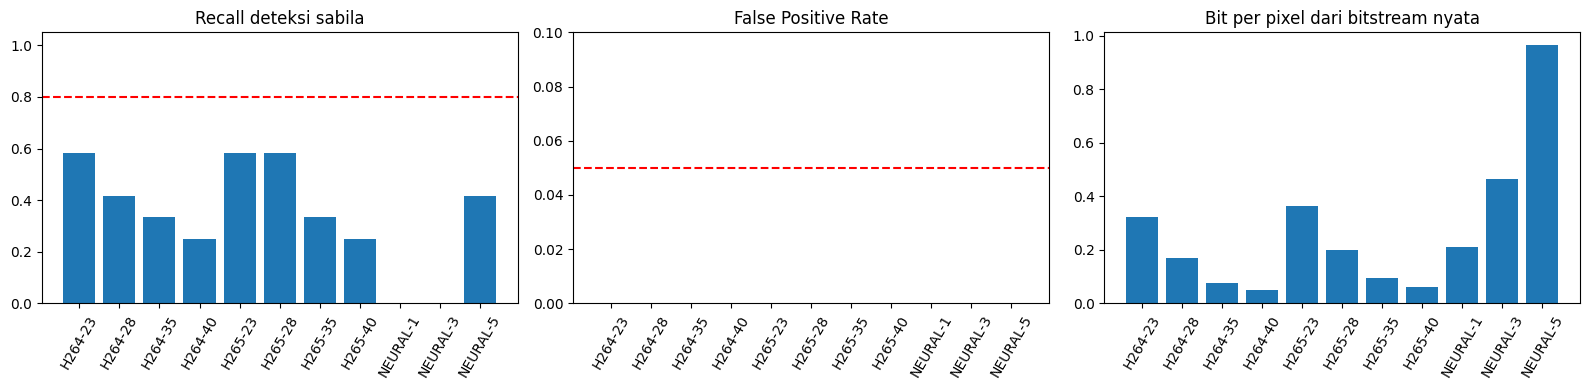

Laporan tersimpan di: /content/drive/MyDrive/Video_data/output/v7_validated/reports


In [26]:
# 13. Visualisasi ringkas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

labels = summary_df['codec'] + '-' + summary_df['level'].astype(str)
axes[0].bar(labels, summary_df['recall_TPR'])
axes[0].axhline(0.80, color='red', linestyle='--')
axes[0].set_title('Recall deteksi sabila')
axes[0].tick_params(axis='x', rotation=60)
axes[0].set_ylim(0, 1.05)

axes[1].bar(labels, summary_df['FPR'])
axes[1].axhline(0.05, color='red', linestyle='--')
axes[1].set_title('False Positive Rate')
axes[1].tick_params(axis='x', rotation=60)
axes[1].set_ylim(0, max(0.1, summary_df['FPR'].max() * 1.2))

axes[2].bar(labels, summary_df['bpp'])
axes[2].set_title('Bit per pixel dari bitstream nyata')
axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
figure_path = REPORT_DIR / 'validated_summary.png'
plt.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
print('Laporan tersimpan di:', REPORT_DIR)


## Cara membaca hasil

Klaim “watermark tahan kompresi tinggi” hanya boleh digunakan jika:

- validation gate berstatus **LULUS**;
- `other_payload` dapat dipulihkan, membuktikan decoder tidak menghafal `sabila`;
- FPR pada `no_watermark` dan `other_payload` tetap rendah;
- recall pada H.264/H.265 CRF 35–40 dan Neural Quality 1 memenuhi target;
- neural compression factor lebih besar dari 1 berdasarkan file `.nvc`;
- kualitas original-versus-watermarked memenuhi batas PSNR/SSIM yang ditentukan.

Jika acceptance report gagal, hasil tersebut tetap merupakan hasil eksperimen yang sah,
tetapi belum mendukung klaim keberhasilan. Tingkatkan data/training atau revisi arsitektur;
jangan mengganti ground truth maupun memaksa output decoder.
